In [1]:
import pandas as pd
import numpy as np
Inputs = pd.read_csv('4din.csv')

Outputs = pd.read_csv('4ddiff.csv')
nInputs = pd.read_csv('n4din.csv')
FA = pd.read_csv('4dFA.csv')

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib 


scaler = StandardScaler()



x_train = scaler.fit_transform(Inputs)
#x_test = scaler.transform(TestInputs)
joblib.dump(scaler, 'new_diffscaler.gz') 

In [3]:
import tensorflow as tf

def cosine_distance(y_true, y_pred):
    y_true = tf.nn.l2_normalize(y_true, axis=-1)
    y_pred = tf.nn.l2_normalize(y_pred, axis=-1)
    return 1 - tf.abs(tf.reduce_sum(y_true * y_pred, axis=-1))

model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(100, activation='relu', input_shape=(12,)),  # 12 input features, 4 vectors each with x, y, z
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(3)  # 3 output features, theta and phi, x y z
])

model.compile(optimizer='adam', loss='mse')


In [4]:
model = tf.keras.models.load_model('new_diffmodel.keras')
modelf = tf.keras.models.load_model('new_FAmodel.keras')

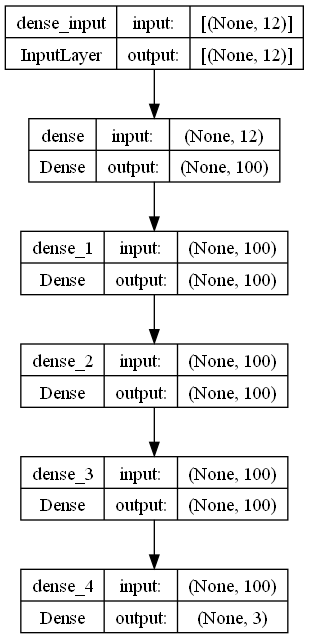

In [4]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_structure.png', show_shapes=True, show_layer_names=True)

In [ ]:
history = model.fit(x_train, Outputs, epochs=16)
model.save('new_diffmodel.h5')

In [8]:
model.save('new_diffmodel.keras')

In [9]:
modelf = tf.keras.models.Sequential([
    tf.keras.layers.Dense(100, activation='relu', input_shape=(12,)),  # 12 input features, 4 vectors each with x, y, z
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1)  # 3 output features, theta and phi, x y z
])

modelf.compile(optimizer='adam', loss='mse')

In [ ]:
history = modelf.fit(x_train, FA, epochs=16)
modelf.save('new_FAmodel.h5')

In [11]:
#modelf.save('new_FAmodel.h5')
modelf.save('new_FAmodel.keras')